Dean Hickman

Fall 2024

CS 251 / 252: Data Analysis and Visualization

Project 4: Principal Component Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import pca

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

np.set_printoptions(suppress=True, precision=5)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

## Task 4: Eigenletters — PCA on images of hand-drawn letters

Here, you will implement an algorithm that uses eigenvectors to reconstruct images based on how the deviate from the mean (i.e. average) image in a library of images. The original algorithm was applied to human faces (here is a [link](https://sites.cs.ucsb.edu/~mturk/Papers/jcn.pdf) to original paper), but we are going to apply it to hand-written letters from the EMNIST data set ([link](https://www.nist.gov/itl/products-and-services/emnist-dataset))

### 4a. Load in the dataset of images of a letter

Run the code below to load in 4,800 images of a single letter (including lower and upper case versions). You can download the file for each letter separately. Change the letter to whichever letter you want (and file you downloaded).

In [2]:
letter = 'e' # You need to choose a letter from the data we made available.
letter_imgs = np.load(f'data/emnist_letter_{letter}.npy')

print(f'There are {letter_imgs.shape[0]} letters. There should be 4800.')
print(f'Shape of images is are {letter_imgs.shape} letters. It should be (4800, 28, 28).')

There are 4800 letters. There should be 4800.
Shape of images is are (4800, 28, 28) letters. It should be (4800, 28, 28).


### 4b. Look at the letter data

In the cell below, fill in the function to create a 12x10 subplots grid of plots (*12 rows, 10 columns*). For showing the image, use [imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html):

Run the function to create the plot of the letters below, with the title "Original".

**Note:**
- When you call `imshow`, add these optional parameters to create black-on-white images: `cmap='gray'`, `vmin=0`, and `vmax=255`
- Turn off the x and y ticks (they just add clutter).


In [3]:
def plot_letter( letter_imgs, title ):
    '''Creates a 12x10 grid of grayscale letter images.
    
    Parameters:
    -----------
    letter_imgs: ndarray. shape=(N, img_y, img_x).
        Grayscale images to show.
    title: string
        Title to display above all the subplots
    
    '''
    fig, axes = plt.subplots(12, 10, figsize=(12, 14))
    fig.suptitle(title, fontsize=20)
    axes = axes.ravel()
    for i in range(120):
        axes[i].imshow(letter_imgs[i], cmap='gray', vmin=0, vmax=255)
        axes[i].axis("off")
    plt.tight_layout() 
    plt.show()

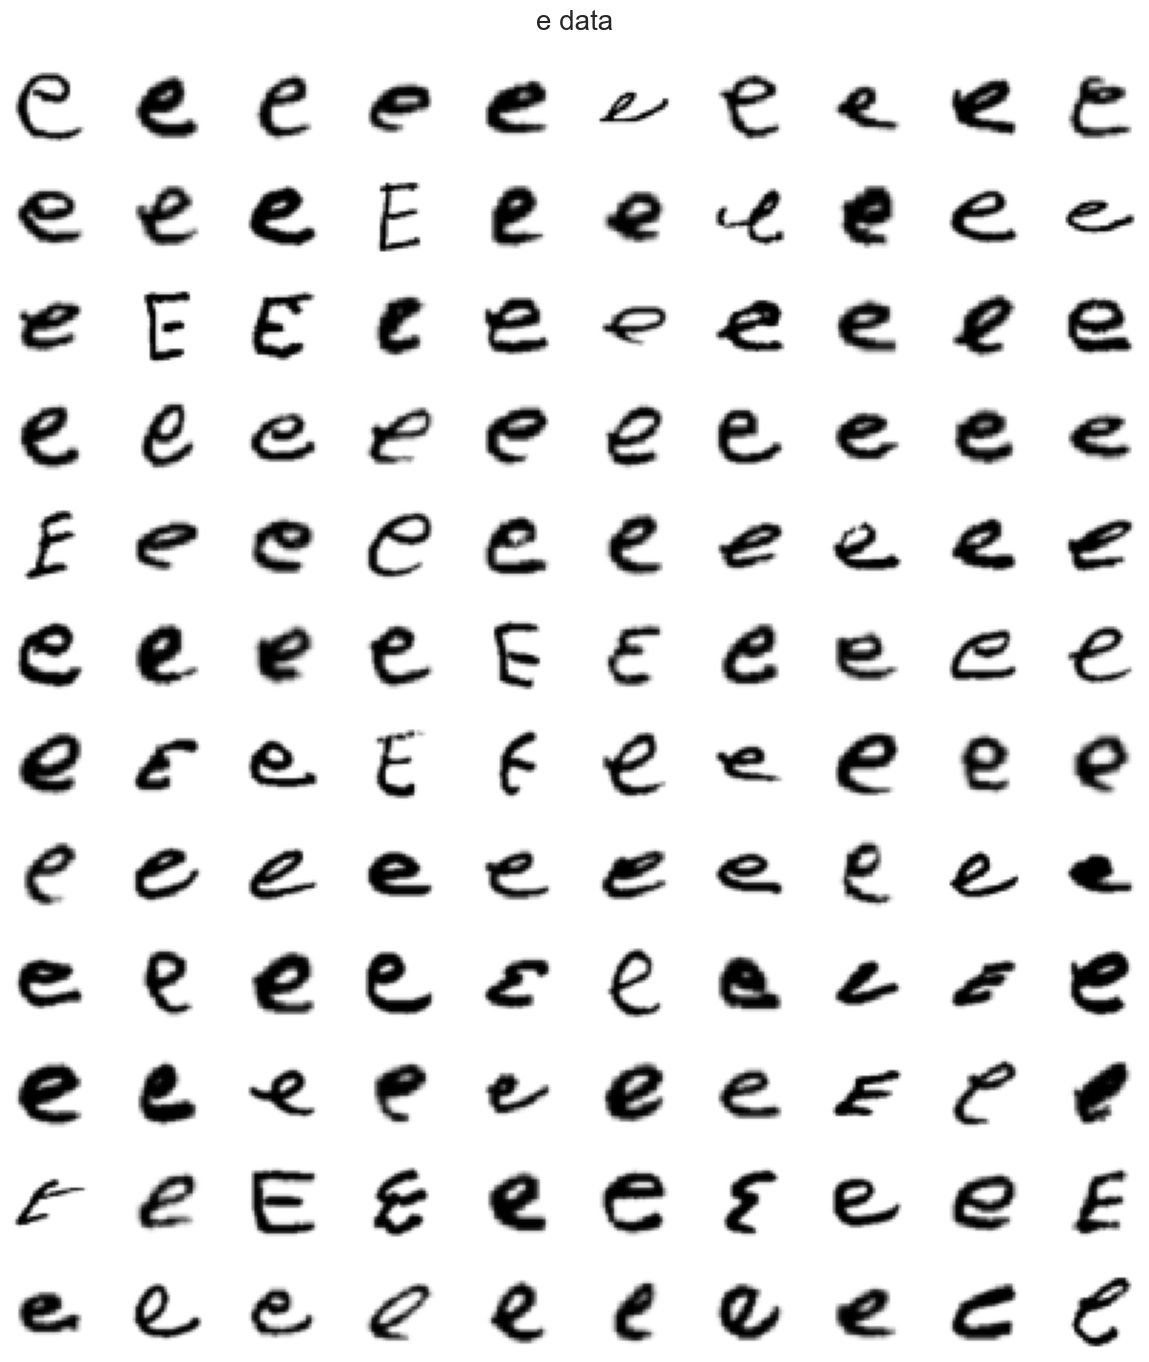

In [4]:
plot_letter(letter_imgs, 'e data')

### 4c. Visualize the "mean letter"

Take the mean of the images and show it below.

**Note:** Use the same `cmap`, `vmin`, and `vmax` parameters as above and turn off x and y tick marks.

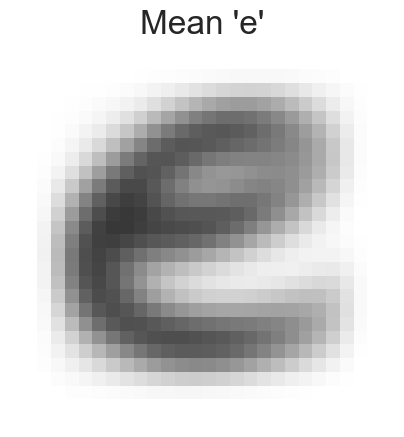

In [5]:
mean_e = np.mean(letter_imgs, axis=0)

plt.figure(figsize=(5, 5))
plt.imshow(mean_e, cmap='gray', vmin=0, vmax=255)
plt.title("Mean 'e'")
plt.axis("off")
plt.show()

### 4d. Preprocess letter data

In the letter dataset, each hand-written letter is a sample and each pixel is a variable. Currently, the latter data has shape = `(4800, 28, 28)` or $N = 4800$ samples and $M = 28*28 = 784$ pixels. To run PCA, we'll need to \"unravel\" each row of pixels and glue them into one big vector so that the shape = `(4800, 28*28)` = `(4800, 784)`. This will make a standard matrix and should work with your PCA code.


In the following cell, reshape the letter data **without hardcoding** ANY of (4800, 28*28)!

In [6]:
num_samples, img_y, img_x = letter_imgs.shape
reshaped_e = letter_imgs.reshape(num_samples, img_y * img_x)

print(f'Reshape: {reshaped_e.shape}')

Reshape: (4800, 784)


### 4e. Perform PCA on preprocessed letter data

Create pandas DataFrame object that holds the letter data then run PCA on the letter dataset. The header names of consecutive integers `0, 1, ..., 783` are fine. For the `vars` parameter in the `fit` method, pass in a Python list of ints (`0, 1, ..., 783`).

**Notes:**
- This is not a "toy" dataset so it might take a few minutes for the PCA to finish computing.
- Use the python `time` module (i.e. `import time`) to time how long the `pca` method takes to finish processing the data, then print out the time elapsed below. If this takes more than a few minutes, something probably is wrong.
- When running the PCA, do not normalize the data. We do not want to treat each pixel as a separate feature.

In [7]:
import time

num_pixel = reshaped_e.shape[1]
pixel_headers = list(range(num_pixel))
letter_df = pd.DataFrame(reshaped_e, columns=pixel_headers)


e_pca = pca.PCA(letter_df)
start = time.time()
e_pca.fit(vars=pixel_headers, normalize_dataset=False)
end = time.time()
print(f"PCA processing time: \n{end - start:.2f} seconds")

mins before normalization: [255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 252 251 228 250
 247 218 218 218 218 218 218 218 218 218 218 218 218 218 218 218 219 226
 255 255 255 255 255 223  72 128  42  38  10   5   1   4   1   5   5   5
   1   1   1   2   5   9   5  11  40 102 242 255 255 255 223  85  38  11
   5   0   0   1   0   0   0   0   0   0   0   0   0   1   1   1   1   1
   1  14 223 255 255 223  42   3   1   1   1   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   1   1   1 130 255 254 167  57   4
   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   1  11 223 255 255 219 142  10   1   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   1   6 192 255 255 222
  54   4   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   1   3 161 255 255 222  70   1   0   0   0   0   0   0
   0   0   0   0   0   0

### 4f. Make letter PCA elbow plot

Make an elbow plot of the PCA results. Show **show only a reasonable number of PCs** to focus on the curve before it plateaus.

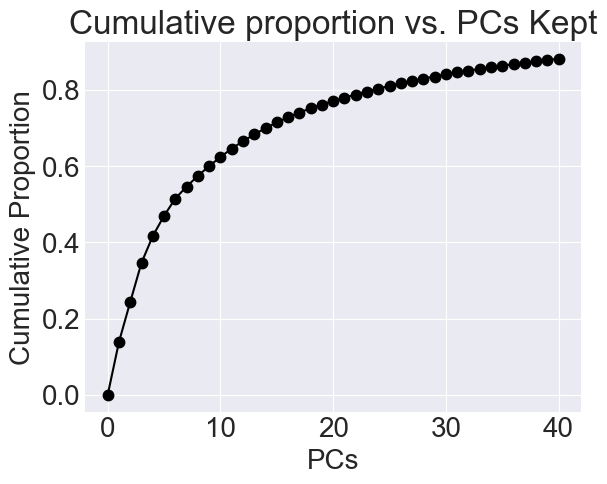

In [8]:
e_pca.elbow_plot(40)


### 4g. Reconstruct letters using the principal components

Use your elbow plot to find the number of top principal components required to *approximately* explain the following cumulative proportion of the variance:
- 20%
- 50%
- 95%

Outline of the general process:
1. For each of the above number of PCs, project them back onto the original data space.
2. Write then use the below `make_imgs` function to convert the projected data back to image shapes `(4800, 28, 28)`.
3. Use `plot_letter` to plot the reconstructed 1st 120 letters with each of the variance numbers above.

**There should be 3 12x10 plots below**

In [9]:
def make_imgs(reconstucted_imgs):
    '''Inflates a 1D feature vector representation of images into 2D images for plotting.
    Assumes square images
    
    Parameters:
    -----------
    reconstucted_imgs: ndarray. shape=(N, img_y*img_x)
        1D vector representation of each image
    
    Returns:
    -----------
    ndarray. shape=(N, img_y, img_x)
        The images inflated into 2D
    '''
    img_size = int(np.sqrt(reconstucted_imgs.shape[1]))
    return reconstucted_imgs.reshape(-1, img_size, img_size)

#### Reconstructed letters with increasing accuracy

Number of PCs for each target variance: [2, 6, 82]


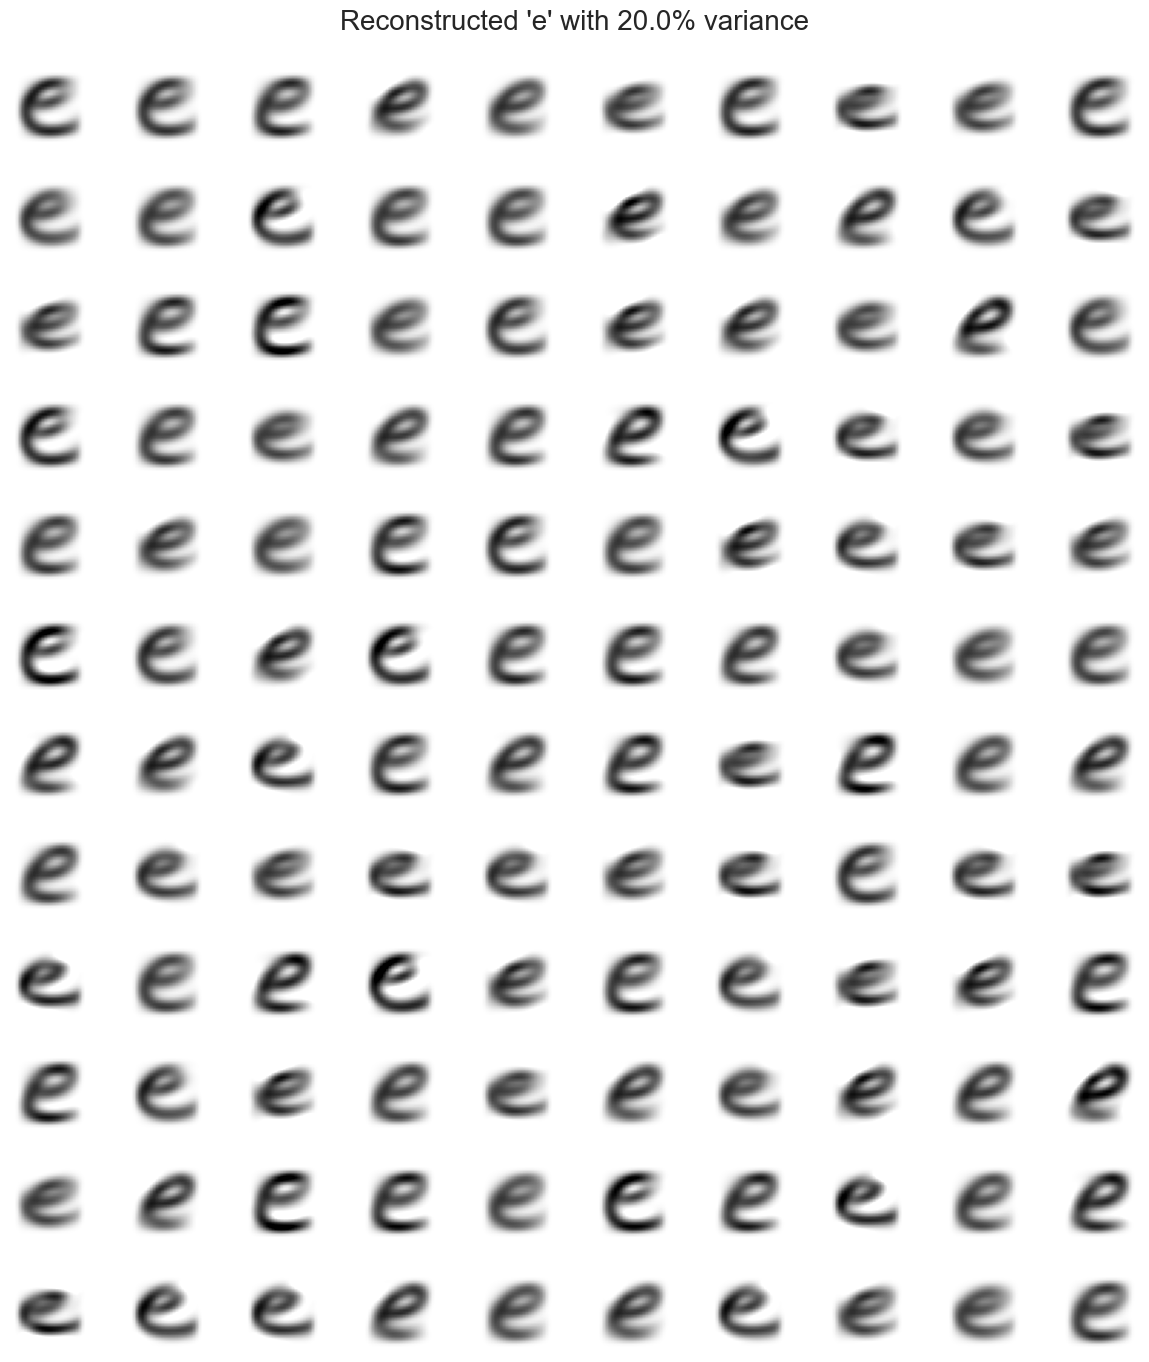

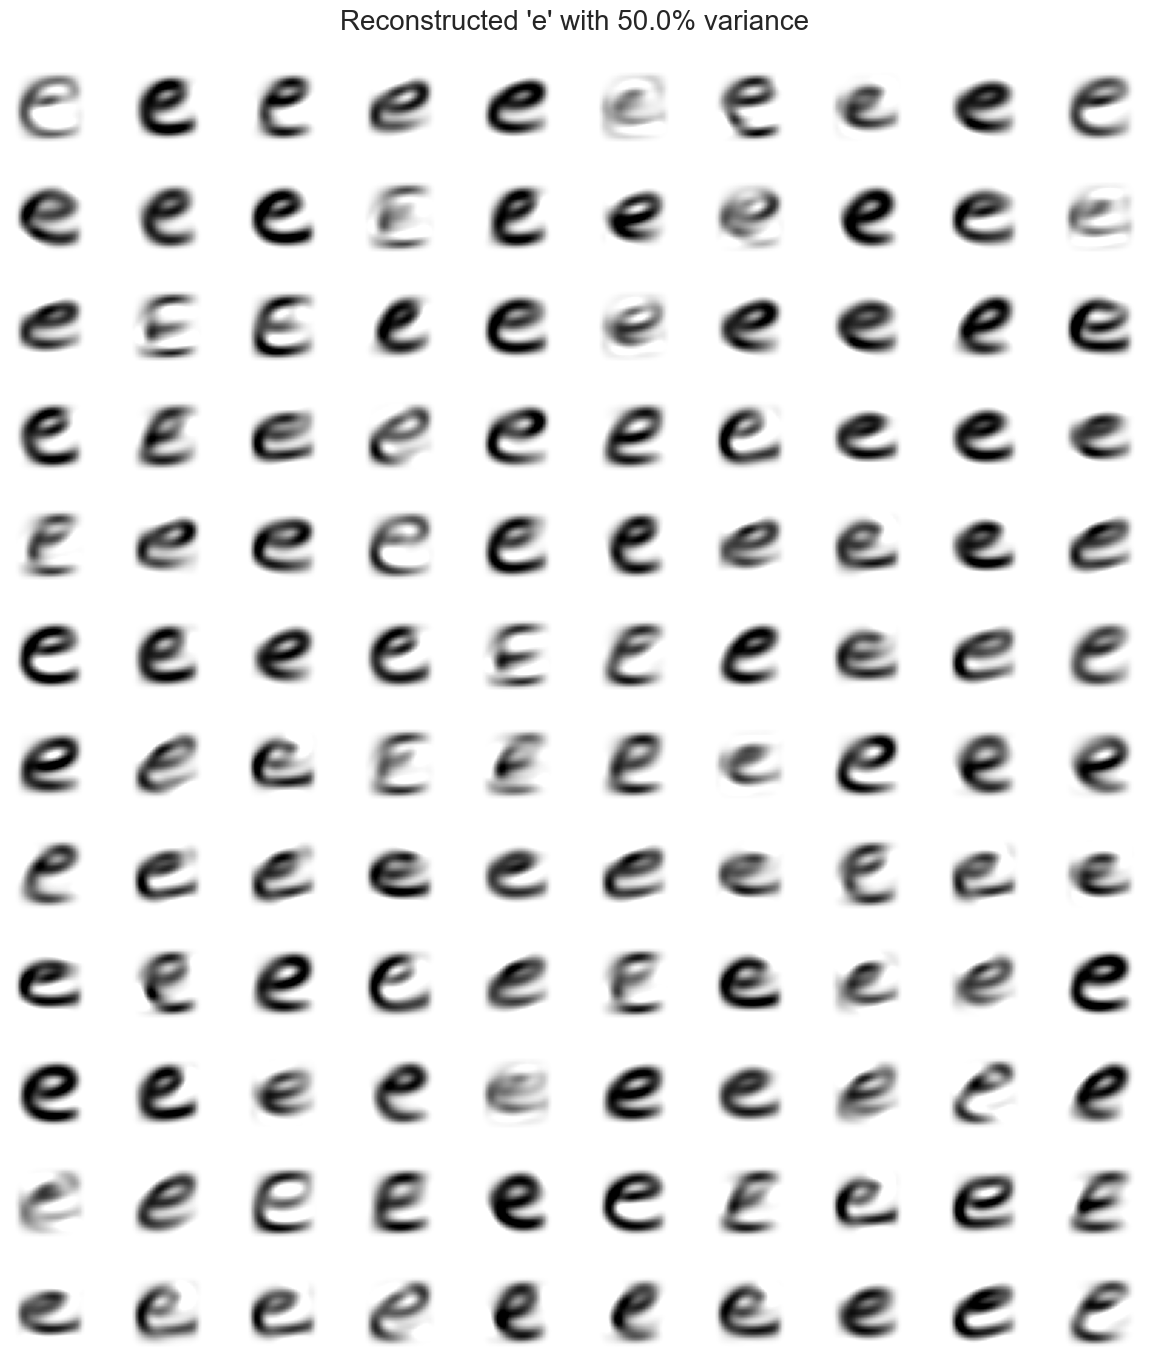

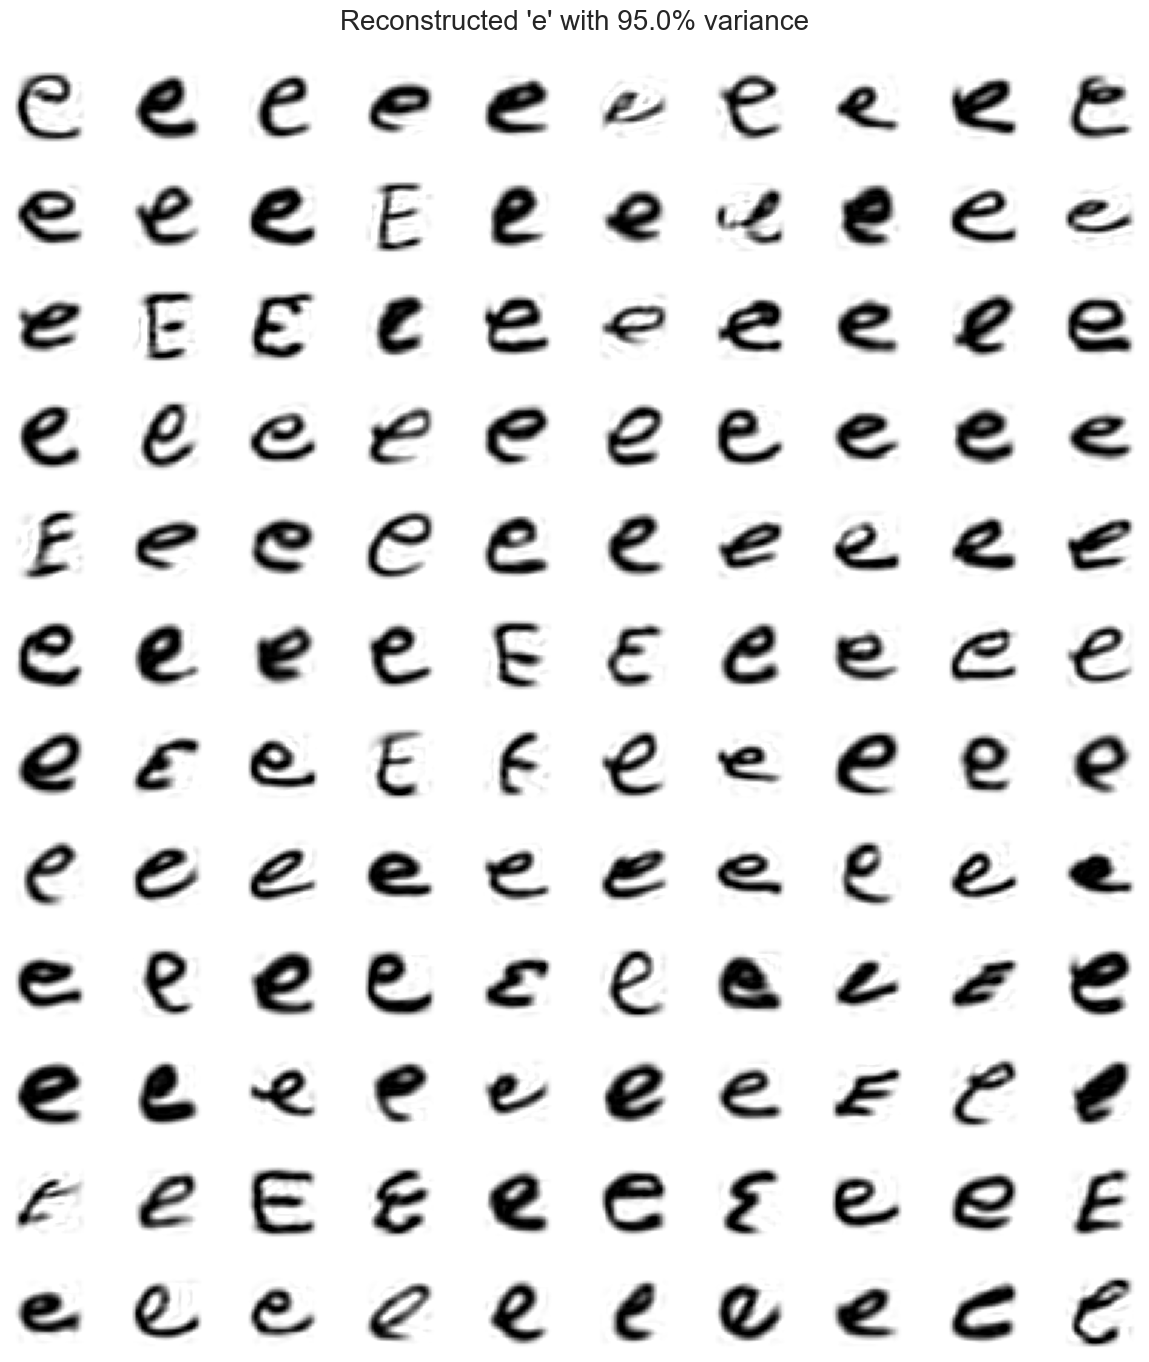

In [10]:
e_pca.cum_var = np.real(e_pca.cum_var)

variances = [0.20, 0.50, 0.95]
num_components = []

for target in variances:
    num_pcs = next(i + 1 for i, cum_var in enumerate(e_pca.cum_var) if cum_var >= target)
    num_components.append(num_pcs)

print(f'Number of PCs for each target variance: {num_components}')  

for variance, k in zip(variances, num_components):
    reconstructed_e = np.real(e_pca.pca_then_project_back(top_k=k)) 
    reconstructed_imgs = make_imgs(reconstructed_e)
    plot_letter(reconstructed_imgs[:120], f"Reconstructed 'e' with {variance*100}% variance")

### 4h. Questions

**Question 12:** Pick one of the letter samples to focus on. Choose one that undergoes a visually interesting transformation as more eigenvectors are used in the reconstruction. Describe what happens visually to the same sample over the course of the reconstructions. Set up 5 plots in a row. The first should be the mean letter (because that is what we start from when we do the reconstruction). The next three should be just that sample with each level of reconstruction (from worst to best). The final plot should be the original data for that sample. Your description should have at least 5 sentences in it.

mins before normalization: [255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 250 218 219 180 187 218 218
 223 223  53 212 236 240 247 236 235 219 218 142 223 179 144  55 149 218
 237 255 255 223   5   8  20   2   5   5  14  10   1  12  50  11  42  42
  54  11  37   5  15   2   1   1   1   4 132 255 255 147   5   1   1   1
   1   0   1   0   1   1   2   1   6   4   4   1   1   1   1   1   1   0
   1   1  41 240 255  38   0   1   1   1   0   0   1   1   0   1   1   1
   1   1   0   1   0   1   1   0   0   0   0   1  40 151 255  38   0   0
   0   0   0   0   0   0   1   1   1   0   0   0   0   1   0   0   0   0
   0   0   0   1  53  84 130  12   1   0   0   0   0   0   0   1   1   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   1  14 233 128   1
   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   1  52 255 240   4   1   0   0   0   0   0   0   0
   0   0   0   0   0   0

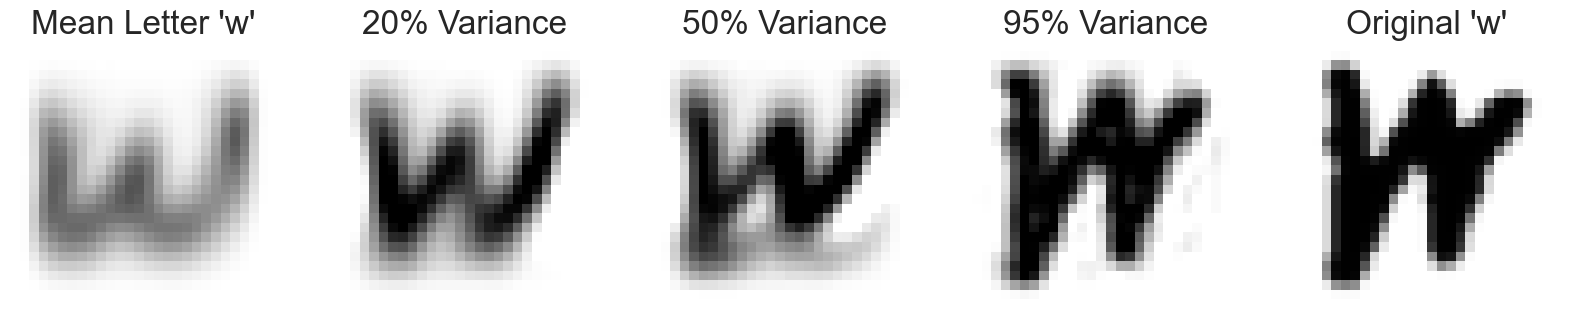

In [13]:
w_data = np.load('data/emnist_letter_w.npy')


if w_data.ndim == 3:
    w_data = w_data.reshape(w_data.shape[0], -1)

pca_w = pca.PCA(pd.DataFrame(w_data))
pca_w.fit(vars=list(range(w_data.shape[1])), normalize_dataset=False)

mean_w = pca_w.A.mean(axis=0).reshape(28, 28)

reconstructed_imgs_20 = np.real(pca_w.pca_then_project_back(top_k=2))
reconstructed_imgs_50 = np.real(pca_w.pca_then_project_back(top_k=7))
reconstructed_imgs_95 = np.real(pca_w.pca_then_project_back(top_k=100))

reconstructed_imgs_20 = reconstructed_imgs_20.reshape(-1, 28, 28)
reconstructed_imgs_50 = reconstructed_imgs_50.reshape(-1, 28, 28)
reconstructed_imgs_95 = reconstructed_imgs_95.reshape(-1, 28, 28)

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

# mean letter
axes[0].imshow(mean_w, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Mean Letter 'w'")
axes[0].axis('off')
# 20% 
axes[1].imshow(reconstructed_imgs_20[0], cmap='gray', vmin=0, vmax=255)
axes[1].set_title("20% Variance") 
axes[1].axis('off')
# 50%
axes[2].imshow(reconstructed_imgs_50[0], cmap='gray', vmin=0, vmax=255)
axes[2].set_title("50% Variance") 
axes[2].axis('off')
# 95%
axes[3].imshow(reconstructed_imgs_95[0], cmap='gray', vmin=0, vmax=255) 
axes[3].set_title("95% Variance") 
axes[3].axis('off')
#original
original_sample = w_data[0].reshape(28, 28) 
axes[4].imshow(original_sample, cmap='gray', vmin=0, vmax=255)
axes[4].set_title("Original 'w'") 
axes[4].axis('off')
plt.show()


**Answer 12:** You can observe from this plot that as we increase the principal components we use to construct the letter, the better we are able to reconstruct the letter. Starting with the mean letter we add principal components to account for increasing amounts of variance. The intuition behind this is that the variance between the mean and any specific instance captures a spread of other instances. In other words, the more variance we add the more instances of the letter we can reconstruct. At 100% of the variance captured we can take the mean letter and make it the original letter, a unqiue instance of the data set. 

**Question 13:** Would it be effective to use the eigenvectors from one letter's data set to project and then project back (i.e. reduce and reconstruct) data from a different letter? 

Either write several sentences with your reasoning or demonstrate it by writing the code to do it. If you do write the code, describe your output and write about whether or not you think your example is representative (e.g. how are your results dependent upon the two letters that you chose?)

**Answer 13:** This would be ineffective because those eigenvectors are very specific to the each letter. The capture meaningful information like variance directions and a basis for the data. It would be very unlikely that the eigenvectors for one letter would help reconstruct another letter. The efficacy of this also comes down to how similar those letters are. Take for instance "l" and "i" you might have a bet shot using their eigenvectors to reconstruct one another but for "O" and "X", surely the reconstruction would not be useful.